In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import zipfile
from torchvision import datasets, transforms
import torch.optim as optim

In [3]:
with zipfile.ZipFile('/content/Transport.zip', 'r' ) as zip_file:
  zip_file.extractall('.')

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])


In [5]:
train_data = datasets.ImageFolder('/content/Transport/train', transform=train_tf)
test_data = datasets.ImageFolder('/content/Transport/test', transform=test_tf)

In [6]:
classess = train_data.classes
classess

['airplane', 'atrain', 'ship', 'tank']

In [7]:
train = DataLoader(train_data, batch_size=32, shuffle=True)
test = DataLoader(test_data, batch_size=32)

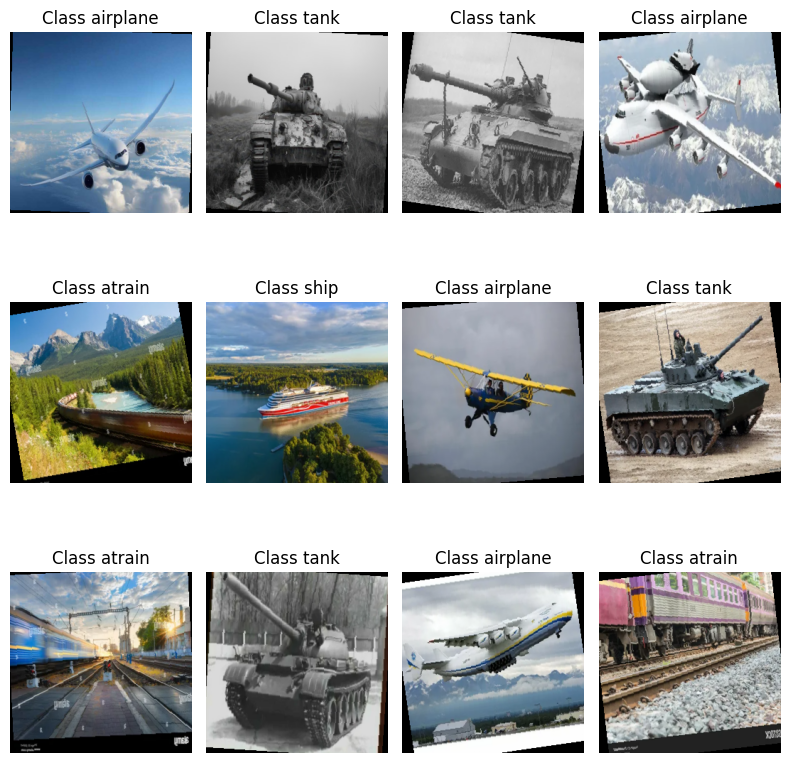

In [8]:
image, label = next(iter(train))
plt.figure(figsize=(8, 10))
for i in range(12):
  plt.subplot(3, 4, i+1)
  plt.imshow(image[i].permute(1, 2, 0))
  plt.title(f'Class {classess[label[i]]}')
  plt.axis('off')
  plt.tight_layout()
plt.show()

In [9]:
class ChechImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.second = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        return self.second(self.first(x))

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [11]:
models1 = ChechImage().to(device)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(models1.parameters(), lr=0.0005)

In [13]:
for epoch in range(30):
  models1.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = models1(x_bath)
    l = loss_fn(y_pred, y_bath)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    total_loss += l.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

Epoch 1, Loss: 130.74
Epoch 2, Loss: 105.81
Epoch 3, Loss: 94.79
Epoch 4, Loss: 89.42
Epoch 5, Loss: 79.43
Epoch 6, Loss: 74.94
Epoch 7, Loss: 66.82
Epoch 8, Loss: 65.53
Epoch 9, Loss: 59.07
Epoch 10, Loss: 57.67
Epoch 11, Loss: 56.35
Epoch 12, Loss: 54.06
Epoch 13, Loss: 51.66
Epoch 14, Loss: 48.46
Epoch 15, Loss: 44.87
Epoch 16, Loss: 45.24
Epoch 17, Loss: 40.79
Epoch 18, Loss: 41.24
Epoch 19, Loss: 37.96
Epoch 20, Loss: 37.69
Epoch 21, Loss: 38.42
Epoch 22, Loss: 34.89
Epoch 23, Loss: 35.75
Epoch 24, Loss: 33.61
Epoch 25, Loss: 31.0
Epoch 26, Loss: 30.73
Epoch 27, Loss: 31.41
Epoch 28, Loss: 33.5
Epoch 29, Loss: 26.33
Epoch 30, Loss: 27.96


In [14]:
models1.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = models1(imgs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 94.06%


In [15]:
torch.save(models1.state_dict(), 'model_transport.pth')